# Analisi Del Dataset House Prices

In [108]:
# loading libraries and dataset


import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statistics as sts

df = pd.read_csv("usa_houses.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


In [109]:
#Data Cleaning in relation to untrustworthy outliers
print("Df_Size before clean:", len(df))
df = df[(df['price'] < 2700000) & (df['price'] > 10000)]
print("Df_Size: after clean", len(df))
print("Min and Max Price:", df['price'].min(), df['price'].max())


Df_Size before clean: 4140
Df_Size: after clean 4077
Min and Max Price: 80000.0 2680000.0


# Piano di Azione

- Comprensione delle colonne del dataset
- Analisi generale contenuti del dataset
- Analisi Forese dati mancati 
- Gestione dei dati mancanti (eliminazione o sostituzione)
- Impostazione heatmap e interpretazione
- Ipostazione Scatterplot e interpretazione 
- Conclusioni, idedentificazione variabili più discriminanti



In [110]:
# Genereral info about the dataset
print(df.columns)
# Check for missing values
print(df.info())


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 4077 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4077 non-null   object 
 1   price          4077 non-null   float64
 2   bedrooms       4077 non-null   float64
 3   bathrooms      4077 non-null   float64
 4   sqft_living    4077 non-null   int64  
 5   sqft_lot       4077 non-null   int64  
 6   floors         4077 non-null   float64
 7   waterfront     4077 non-null   int64  
 8   view           4077 non-null   int64  
 9   condition      4077 non-null   int64  
 10  sqft_above     4077 non-null   int64  
 11  sqft_basement  4077 non-null   int64  
 12  yr_built    

In [111]:
# Descriptive general statistics
describe_df = df.describe()
describe_df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.077000e+03,4077.000000,4077.000000,4077.000000,4.077000e+03,4077.000000,4077.000000,4077.000000,4077.000000,4077.000000,4077.000000,4077.000000,4077.000000
mean,5.418975e+05,3.390728,2.150601,2124.253127,1.465005e+04,1.513613,0.005887,0.233996,3.450331,1818.143243,306.109885,1970.797400,808.143488
std,3.273215e+05,0.897408,0.765666,915.404376,3.601239e+04,0.534849,0.076508,0.764582,0.675375,836.586921,450.857995,29.858493,979.341608
min,8.000000e+04,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.250000e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.630000e+05,3.000000,2.250000,1970.000000,7.644000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.599500e+05,4.000000,2.500000,2610.000000,1.089000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000
max,2.680000e+06,8.000000,6.500000,7320.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,7320.000000,2850.000000,2014.000000,2014.000000


In [112]:
# Double check for missing values and duplicates

print("\nMissing values:\n",df.isna().sum())

print("\nDuplicates:", df.duplicated().sum())   


Missing values:
 date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Duplicates: 0


# Matrice di correlazione

In [113]:
# Correlation matrix to identify relevant variables
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.332237,0.521961,0.681057,0.079679,0.269069,0.137929,0.356124,0.052707,0.585216,0.296897,0.031535,-0.053311
bedrooms,0.332237,1.000000,0.541330,0.594894,0.067271,0.174462,-0.019215,0.099132,0.012801,0.475710,0.325150,0.151594,-0.072365
bathrooms,0.521961,0.541330,1.000000,0.750336,0.097411,0.495686,0.030932,0.181287,-0.127270,0.678938,0.263654,0.476908,-0.231788
sqft_living,0.681057,0.594894,0.750336,1.000000,0.199394,0.348880,0.059401,0.280375,-0.071586,0.871339,0.413552,0.301355,-0.133811
sqft_lot,0.079679,0.067271,0.097411,0.199394,1.000000,-0.001054,0.020020,0.068633,0.012813,0.206414,0.021830,0.045718,-0.019282
floors,0.269069,0.174462,0.495686,0.348880,-0.001054,1.000000,0.010032,0.025506,-0.276425,0.528144,-0.271643,0.469579,-0.236486
waterfront,0.137929,-0.019215,0.030932,0.059401,0.020020,0.010032,1.000000,0.324554,0.010408,0.035757,0.054256,-0.048021,0.021472
view,0.356124,0.099132,0.181287,0.280375,0.068633,0.025506,0.324554,1.000000,0.063373,0.145924,0.298494,-0.075417,0.032368
condition,0.052707,0.012801,-0.127270,-0.071586,0.012813,-0.276425,0.010408,0.063373,1.000000,-0.185839,0.199487,-0.402724,-0.185707
sqft_above,0.585216,0.475710,0.678938,0.871339,0.206414,0.528144,0.035757,0.145924,-0.185839,1.000000,-0.086411,0.421180,-0.171390


# Heatmap

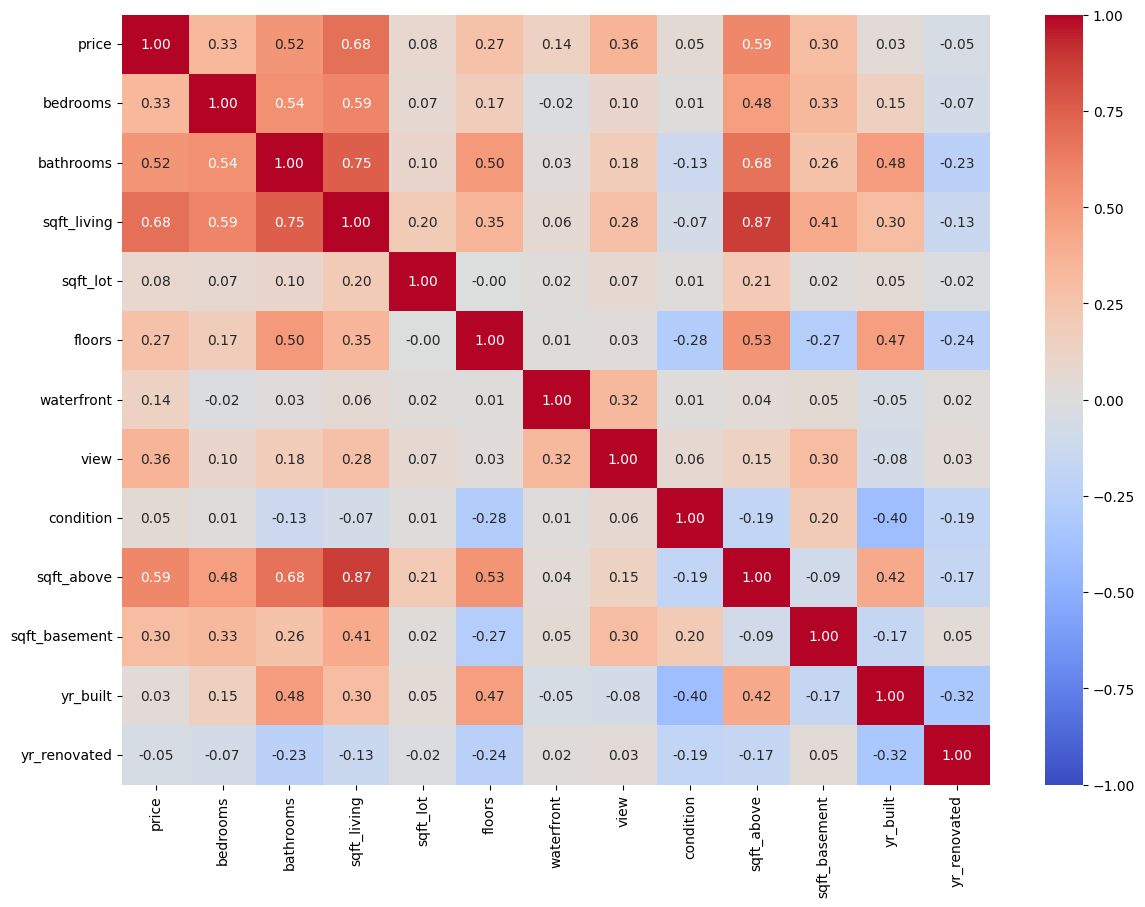

In [114]:
# Visualizing the correlation matrix in a hetmap style
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)

plt.show()

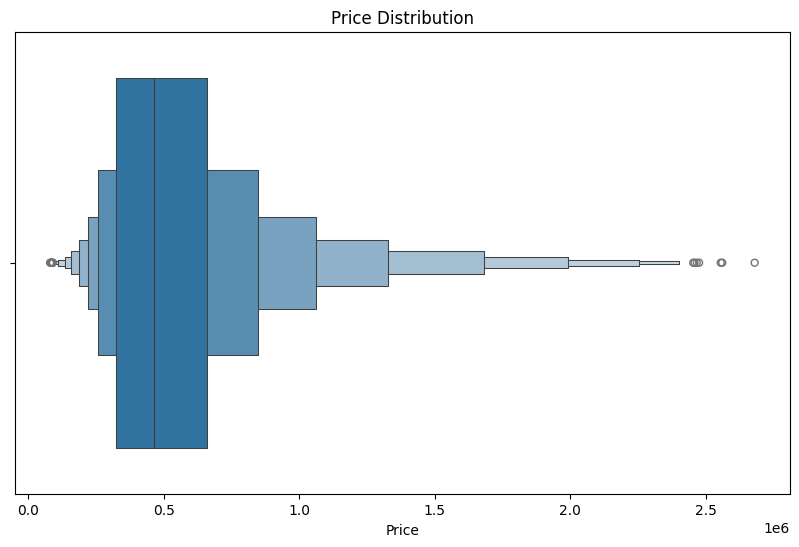

In [115]:
# Visualizing the price distribution to identify outliers
plt.figure(figsize=(10,6))
sns.boxenplot(x=df['price'])
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

# In conclusione le variabili rilevanti che useremmo per un modello di regressione sarebbero:
- sqft_linving > Gestisce lo spazio in generale , in parte anche camere da letto e bagni, e influenza piu il prezzo
- wiev > Gestisce una caratteristica isolata e discriminante che ha una relazione elevata con il prezzo ma non lo spazio il che la rende eccellente
- waterfront > Gestisce in modo piu marginale il prezzo e sembra avere una relazione abbastanza alta con la vista, tuttavia aggiunge informazioni in piu
- floors  > Influenza il prezzo in modo relativamente significativo senza avere una relazione troppo alta con la metratura della casa, quindi aggiunge informazioni.